## Etapa 1 - Importar bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuração visual
pd.set_option('display.max_columns', None)

---

## Etapa 2 - Carregar Dados

In [17]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---

## Etapa 3 - Análise Exploratória de Dados (EDA)

### Pagamentos

In [6]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### Serviço de internet

In [7]:
pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Serviço de Streaming

In [18]:
pd.crosstab(
    [df['StreamingTV'], df['InternetService']],
    df['Churn'],
    normalize='index'
) * 100

Churn                                       No        Yes
StreamingTV         InternetService                      
No                  DSL              77.322404  22.677596
                    Fiber optic      54.680535  45.319465
No internet service No               92.595020   7.404980
Yes                 DSL              86.729363  13.270637
                    Fiber optic      60.742857  39.257143

### Senior Citizen (Pessoas com ou acima de 65 anos)

In [8]:
pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


### Dependentes

In [9]:
pd.crosstab(
    df['Dependents'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


### Parceiro

In [12]:
pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


### Monthly Charges (Pagamentos mensais)

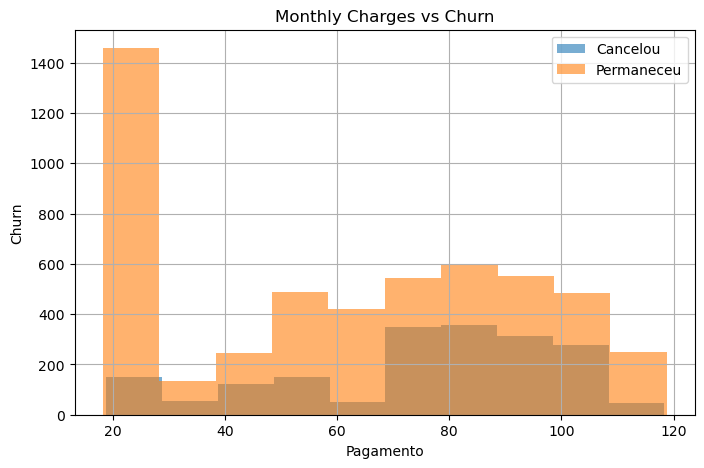

In [15]:
plt.figure(figsize=(8,5))

df[df['Churn']=='Yes']['MonthlyCharges'].hist(alpha=0.6, label='Cancelou')
df[df['Churn']=='No']['MonthlyCharges'].hist(alpha=0.6, label='Permaneceu')

plt.legend()
plt.xlabel('Pagamento')
plt.ylabel('Churn')
plt.title('Monthly Charges vs Churn')
plt.show()

---

 ## Análise sobre a EDA

Clientes que utilizam Electronic Check apresentaram maior taxa de churn em comparação aos demais métodos de pagamento. Isso pode indicar menor fidelização ou um perfil de cliente mais propenso ao cancelamento, exigindo investigação adicional.

Clientes com serviço de fibra óptica apresentaram maior probabilidade de churn, sugerindo possível desalinhamento entre custo, qualidade percebida ou expectativa do serviço

Clientes classificados como senior citizen apresentaram maior propensão ao churn, sugerindo possível necessidade de estratégias específicas de retenção para esse segmento.

Para quem tem dependentes a chance de churn é muito menor. E o mesmo para quem tem parceiros, a chance de churn é muito menor.

Sobre os pagamentos mensais (monthly charges), pessoas que pagam menos em suas assinaturas permanecem. Quem paga MAIS cancela MAIS.

Um adicional seria o Streaming TV, pessoas que assinam Streaming TV + Internet tem 30,07% de chance de Churn, já pessoas que apenas assinam a Streaming TV tem 7,4% de chance de Churn.